# Analyse results from Pypsa-Earth
This notebook reads the latest optimization described in the config.yaml file and makes plots and summaries of the results.

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Import packages

In [1]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)
# change current directory to parent folder
if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")

PARENT = os.path.realpath("pypsa-earth/") + "/"
# Specify config name
CONFIG = "config-EG-sec-2050-0_50_100_200_300_400_800_1000TWh"
config = yaml.safe_load(open(PARENT + "own-configs/" + CONFIG + ".yaml"))

In [5]:
run_name = config["run"]["name"]
run_sector_name = config["run"]["sector_name"]                          
simpl = config["scenario"]["simpl"]    
clust = config["scenario"]["clusters"]   
ll = config["scenario"]["ll"]             
load_scale = config["load_options"]["scale"]               
opts = config["scenario"]["opts"]       
sopts = config["scenario"]["sopts"]              
planning = config["scenario"]["planning_horizons"]        
discountrate = config["costs"]["discountrate"]                
demand = config["scenario"]["demand"]                  
# export_value = config["export"]["h2export"]  
export_value = [400]                

# Process each setting into a string representation 
simpl_str = "_".join(map(str, simpl))   
clust_str = "_".join(map(str, clust))    
ll_str = "l" + "_".join(map(str, ll))           
scale_str = f"lc{load_scale}"                           
opts_str = "_".join(map(str, opts))    
sopts_str = "_".join(map(str, sopts))                 
planning_str = "_".join(map(str, planning))               
dr_str = "_".join(map(str, discountrate))             
demand_str = "_".join(map(str, demand))                    
export_str = "_".join(map(str, export_value)) + "export"

scenario_subpath = f"{run_name}/" if run_name else ""

nc_file_name = (
    f"elec_s_{clust_str}_ec_{ll_str}_{opts_str}_{sopts_str}_"
    f"{planning_str}_{dr_str}_{demand_str}_{export_str}.nc"
)

# Country shape file
regions_onshore_path = PARENT + f"resources/{scenario_subpath}shapes/country_shapes.geojson"

# Results path
results_path = PARENT + f"results/{run_sector_name}/postnetworks/{nc_file_name}"

## Analysis Network Setup

In [7]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

Index(['CO2 pipeline EG.10_1_AC <-> EG.18_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.2_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.12_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.15_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.16_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.16_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.1_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.5_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.9_1_AC',
       'CO2 pipeline EG.13_1_AC <-> EG.25_1_AC',
       'CO2 pipeline EG.14_1_AC <-> EG.17_1_AC',
       'CO2 pipeline EG.14_1_AC <-> EG.25_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.22_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.26_1_AC',
       'CO2 pipeline EG.15_

## Data import check

Plot of the region of interest

In [8]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

GEOSException: IllegalArgumentException: Points of LinearRing do not form a closed linestring

List number of components by type

In [6]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 24 entries
Component 'Carrier' has 19 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 4 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 30 entries
Component 'Load' has 6 entries
Component 'Generator' has 37 entries
Component 'StorageUnit' has 2 entries
Component 'Store' has 18 entries


List the snapshots of the PyPSA network

In [9]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 03:00:00',
               '2013-01-01 06:00:00', '2013-01-01 09:00:00',
               '2013-01-01 12:00:00', '2013-01-01 15:00:00',
               '2013-01-01 18:00:00', '2013-01-01 21:00:00',
               '2013-01-02 00:00:00', '2013-01-02 03:00:00',
               ...
               '2013-12-30 18:00:00', '2013-12-30 21:00:00',
               '2013-12-31 00:00:00', '2013-12-31 03:00:00',
               '2013-12-31 06:00:00', '2013-12-31 09:00:00',
               '2013-12-31 12:00:00', '2013-12-31 15:00:00',
               '2013-12-31 18:00:00', '2013-12-31 21:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=2920, freq=None)
Time steps: 2920


## Analyse energy system

Analyse the current capacity of the energy system - map view

In [13]:
n.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
Carrier,,,,,
CCGT,0.198,#b80404,Combined-Cycle Gas,inf,0.0
geothermal,0.120,#ba91b1,Geothermal,inf,0.0
nuclear,0.000,#ff9000,Nuclear,inf,0.0
hydro,0.000,#08ad97,Reservoir & Dam,inf,0.0
offwind-ac,0.000,#6895dd,Offshore Wind (AC),inf,0.0
offwind-dc,0.000,#74c6f2,Offshore Wind (DC),inf,0.0
onwind,0.000,#235ebc,Onshore Wind,inf,0.0
solar,0.000,#f9d002,Solar,inf,0.0
PHS,0.000,#08ad97,Pumped Hydro Storage,inf,0.0


/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


ValueError: Colors not defined for all elements in the second MultiIndex 

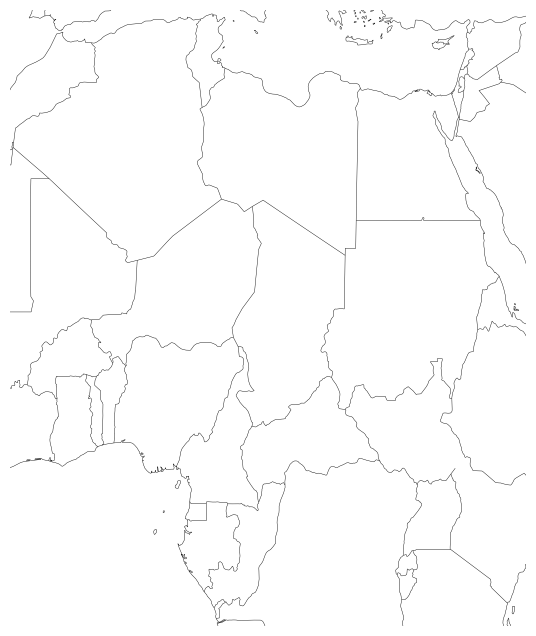

In [15]:
# Scale settings
bus_scale = 6e3 
line_scale = 6e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

#n.carriers.drop("load", inplace=True)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses[n.buses.carrier == 'AC'].x.mean())})
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links.p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

In [24]:
os.cwd()

AttributeError: module 'os' has no attribute 'cwd'

In [27]:
import pathlib

# Read colors from colors.txt and update n.carriers DataFrame
notebook_path = str(pathlib.Path().resolve())
print("Notebook location:", notebook_path)
colors_path = "pypsa-earth-docu/notebooks/colors.txt"
with open(colors_path, "r") as f:
    color_lines = f.readlines()

color_dict = {}
for line in color_lines:
    if ":" in line:
        key, value = line.strip().split(":", 1)
        color_dict[key.strip().lower()] = value.strip().strip('"').strip("'")

# Update n.carriers.color where possible
for idx in n.carriers.index:
    carrier_name = idx.lower()
    if carrier_name in color_dict:
        n.carriers.at[idx, "color"] = color_dict[carrier_name]

Notebook location: /Users/marcoschamel/git-marco


In [28]:
n.carriers.color

Carrier
CCGT                                           #b80404
geothermal                                     #ba91b1
nuclear                                              r
hydro                                          #08ad97
offwind-ac                                     #6895dd
offwind-dc                                     #74c6f2
onwind                                         #235ebc
solar                                          #f9d002
PHS                                            #08ad97
ror                                            #4adbc8
co2                                            #123456
gas                                            #d35050
oil                                            #262626
coal                                                 k
lignite                                           grey
biomass                                        #0c6013
H2                                             #ea048a
battery                                      slategray
re

/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


ValueError: Colors not defined for all elements in the second MultiIndex 

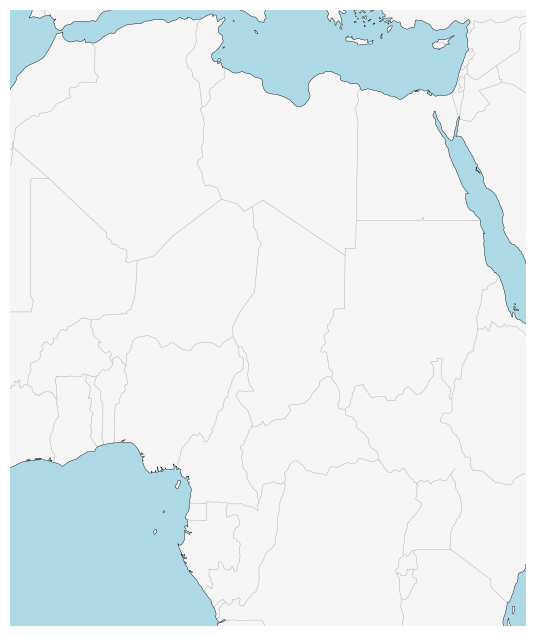

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses[n.buses.carrier == 'AC'].x.mean())})
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom / line_scale,
        link_widths=n.links.p_nom / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap="green",
    )
# regions_onshore.plot(
#     ax=ax,
#     facecolor="whitesmoke",
#     edgecolor="white",
#     aspect="equal",
#     transform=ccrs.PlateCarree(),
#     linewidth=0,
# )
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
# circles legend may requite some fine-tuning
legend_circles_dict = {"bbox_to_anchor": (1, 1.0), "labelspacing": 2.5, **legend_kwargs}
bus_sizes = [100, 2e3]  # in MW
line_sizes = [2000, 5000]  # in MW
add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()
# fig.savefig(OUTPUT, bbox_inches="tight", dpi=300)



######



In [18]:
n.carriers.color

Carrier
CCGT                                         #b80404
geothermal                                   #ba91b1
nuclear                                      #ff9000
hydro                                        #08ad97
offwind-ac                                   #6895dd
offwind-dc                                   #74c6f2
onwind                                       #235ebc
solar                                        #f9d002
PHS                                          #08ad97
ror                                          #4adbc8
co2                                                 
gas                                                 
oil                                                 
coal                                                
lignite                                             
biomass                                             
H2                                                  
battery                                             
residential rural heat                

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

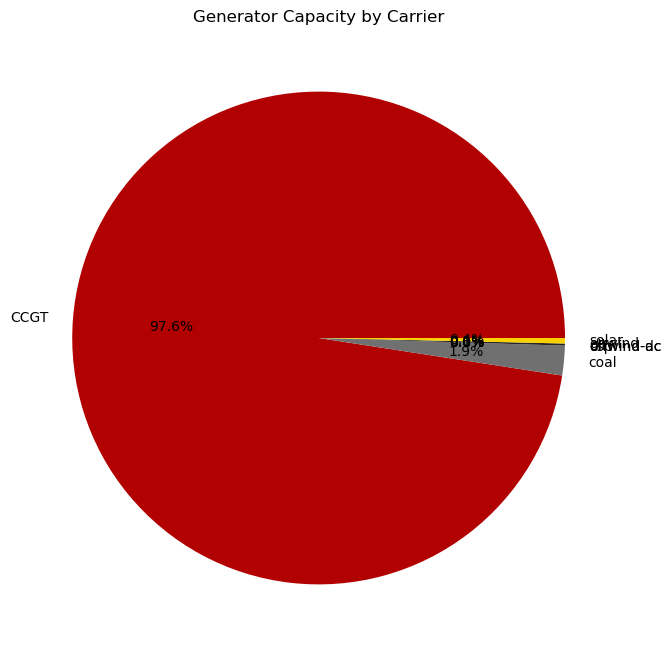

In [9]:
generator_capacity_by_carrier = (
    n.generators[n.generators.carrier != "load"]
    .groupby(["carrier"])
    .p_nom.sum()
)
plt.figure(figsize=(8, 8))
plt.pie(
    generator_capacity_by_carrier,
    labels=generator_capacity_by_carrier.index,
    autopct='%1.1f%%',
    colors=n.carriers[
            n.carriers.index.isin(generator_capacity_by_carrier.index)
        ].color.reindex(generator_capacity_by_carrier.index)
)
plt.title("Generator Capacity by Carrier")

Analyse the current gernation capacity of the energy system - tabular view

In [10]:
generator_capacity_by_carrier/1e3 # in GW

carrier
CCGT          14.301806
coal           0.284500
csp            0.000000
offwind-ac     0.000000
offwind-dc     0.000000
oil            0.020000
onwind         0.000000
solar          0.052301
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

/home/aca39878/anaconda3/envs/pypsa-earth/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



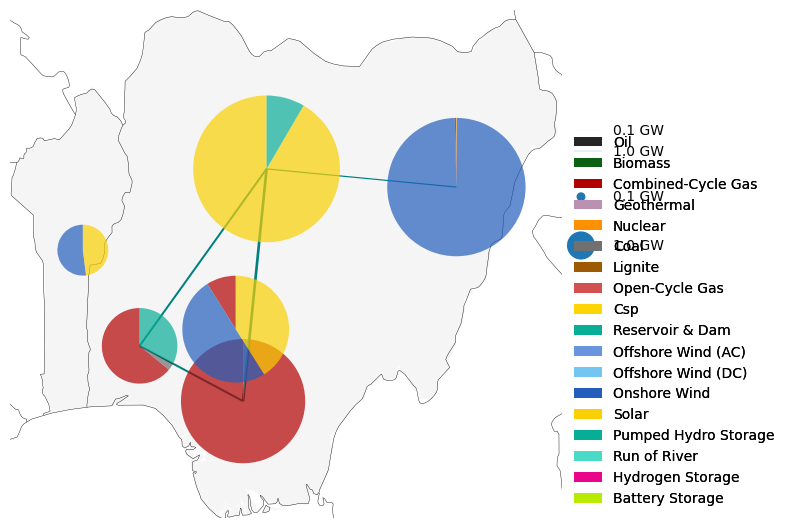

In [11]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links.p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Analys the future generation capacity expansion of the energy system - bar chart

<AxesSubplot:title={'center':'Generator capacity expansion in GW'}, xlabel='carrier'>

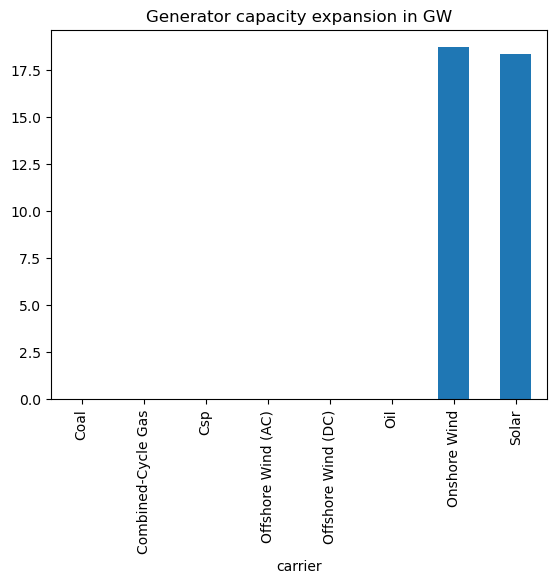

In [12]:
optimal_capacity = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)
installed_capacity = n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion = optimal_capacity - installed_capacity
generation_capacity_expansion.drop(["load"], inplace=True)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Plot the future generation capacity expansion of the energy system - tabular chart

In [13]:
generation_capacity_expansion # In GW

carrier
Coal                   0.000000
Combined-Cycle Gas     0.000000
Csp                    0.000000
Offshore Wind (AC)     0.000000
Offshore Wind (DC)     0.000000
Oil                    0.000000
Onshore Wind          18.724144
Solar                 18.370978
dtype: float64

Analyse the future energy generation of the energy system - bar chart view

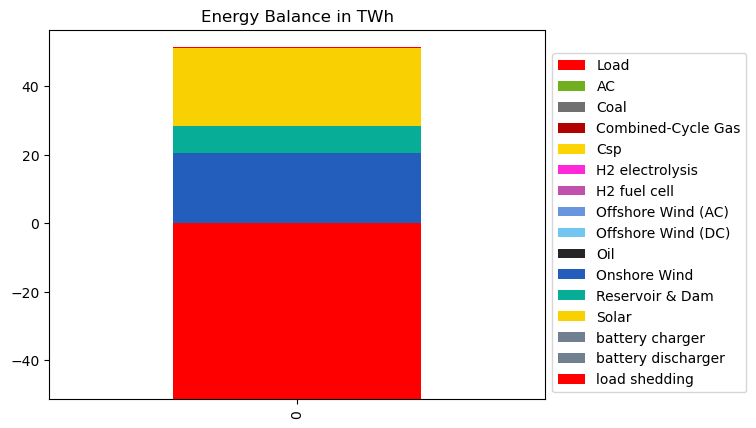

In [14]:
colors = {key.lower(): value.lower() for key, value in config["plotting"]["tech_colors"].items()}
nice_names = {value.lower(): key for key, value in config["plotting"]["nice_names"].items()}

rename_cols = {
    '-': 'Load',
    'load': 'load shedding',
}

energy_balance = (
    n.statistics.energy_balance()
    .loc[:, :, "AC"]
    .groupby("carrier")
    .sum()
    .div(1e6)
    .to_frame()
    .T
    .rename(columns=rename_cols)
)

# color-matching
color_list = []
for col in energy_balance.columns:
    original_name = col.lower()
    key_name = nice_names.get(original_name, original_name)
    color = colors.get(key_name.lower(), 'gray')
    color_list.append(color)


fig, ax = plt.subplots()
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh", color=color_list)
handles, labels = ax.get_legend_handles_labels()
nice_labels = [config["plotting"]["nice_names"].get(label, label) for label in energy_balance.columns]
ax.legend(handles, nice_labels, bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

plt.show()

Analyse the future energy generation of the energy system - tabular view

In [15]:
n.statistics.energy_balance()/1e6 # In TWh

             carrier             bus_carrier
Load         -                   AC            -5.133406e+01
Generator    Coal                AC             0.000000e+00
             Combined-Cycle Gas  AC             1.660025e-02
             Csp                 csp            0.000000e+00
             Offshore Wind (AC)  AC             0.000000e+00
             Offshore Wind (DC)  AC             0.000000e+00
             Oil                 AC             0.000000e+00
             Onshore Wind        AC             2.063057e+01
             Solar               AC             2.277725e+01
             load                AC             8.922972e-02
Link         Csp                 AC             0.000000e+00
                                 csp            0.000000e+00
             H2 electrolysis     AC            -5.138653e-02
                                 H2             3.494284e-02
             H2 fuel cell        AC             1.747143e-02
                                 H2     

## Analyse pv and wind potential - map view

In [16]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br = gpd.read_file(f"{PARENT}resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot wind energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


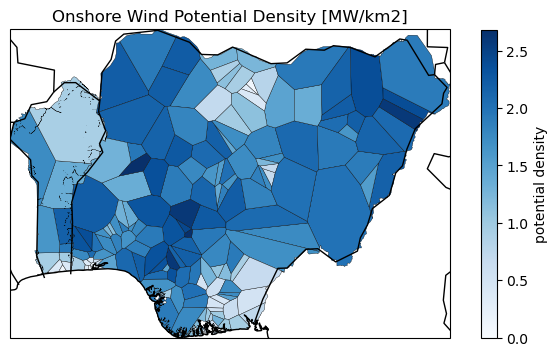

In [17]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot pv energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


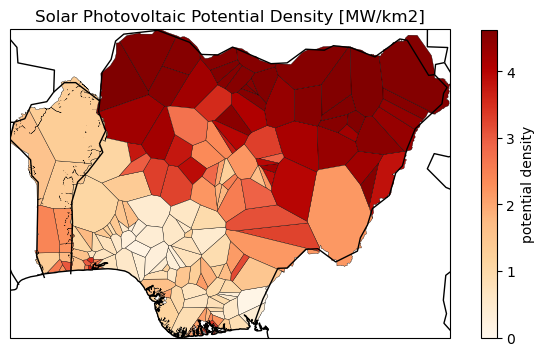

In [18]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)